In [1]:
import os, sys, glob, re, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
try:
    nb_path = globals().get('__vsc_ipynb_file__')
    if nb_path:
        os.chdir(os.path.dirname(os.path.dirname(nb_path)))
except Exception as e:
    print(f"Could not change directory: {e}")
print("CWD:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config
cdt = importlib.import_module("04_cross_dataset_training")
%matplotlib inline

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## 1. Decode the temperature grid

The temperature sensors sit at the **centre of each 5x5 block**, i.e.
`arr[2::5, 2::5]` over the (290, 204) pixel array, giving 58 x 41 = 2378
sensors. Pixel blocks are stored Fortran-order, so flat index = `col*290 + row`.

Only the per-frame tail plus those 2378 columns are read -- the 55M-word pixel
block is never materialized in full.

In [3]:
P_PIX, NROWS, NCOLS = 290 * 204, 290, 204
GROUP = "final_6_new"
ROOT = config.FINAL_EXP_FOLDER
CACHE = Path("notebooks/_cache_temp_curves.joblib")

def short(f):
    m = re.search(r"DDM_0(\d)", f)
    return f"Chip 0{m.group(1)}" if m else f

CHIPS = sorted(config.CROSS_DATASET_GROUPS[GROUP],
               key=lambda s: int(re.search(r"DDM_0(\d)", s).group(1)))

TEMP_ROWS = np.arange(2, NROWS, 5)
TEMP_COLS = np.arange(2, NCOLS, 5)
_tr, _tc = np.meshgrid(TEMP_ROWS, TEMP_COLS, indexing="ij")
TEMP_FLAT = (_tc * NROWS + _tr).ravel()          # Fortran-order flat index

# split_wells is applied to the (58,41) TEMP array (load_and_preprocessing.py:331),
# NOT to the 290x204 array. Mirror np.array_split exactly:
#   rows = array_split(arr, 5, axis=0); each -> array_split(row, 2, axis=1)
N_TR, N_TC = len(TEMP_ROWS), len(TEMP_COLS)
TEMP_WELL_GRID = np.empty((N_TR, N_TC), dtype=int)
_w = 0
for _rblk in np.array_split(np.arange(N_TR), 5, axis=0):
    for _cblk in np.array_split(np.arange(N_TC), 2, axis=0):
        TEMP_WELL_GRID[np.ix_(_rblk, _cblk)] = _w
        _w += 1
TEMP_WELL = TEMP_WELL_GRID.ravel()
print(f"temp grid {N_TR}x{N_TC} = {N_TR*N_TC} sensors; "
      f"sensors/well = {np.bincount(TEMP_WELL).tolist()}")

temp grid 58x41 = 2378 sensors; sensors/well = [252, 240, 252, 240, 252, 240, 231, 220, 231, 220]


In [4]:
def decode_temp_curves(chip):
    """(n_time, 2378) raw temperature traces for ref slice 0."""
    fs = sorted(glob.glob(os.path.join(ROOT, chip, "*readout_time.bin")))
    if not fs:
        return None
    d = np.fromfile(fs[-1], dtype=">u2")
    for n_refs in (1, 2, 3):
        A = n_refs + 10
        N = P_PIX * n_refs + A
        if len(d) % N == 0 and int(d[P_PIX * n_refs]) == 11:
            nfr = len(d) // N
            block = d.reshape(nfr, N)[:, :P_PIX]
            return block[:, TEMP_FLAT].astype(np.float32)
    return None

if CACHE.exists():
    TC = joblib.load(CACHE)
    print(f"loaded cache: {[(short(c), v.shape) for c, v in TC.items()]}")
else:
    TC = {}
    for chip in CHIPS:
        cur = decode_temp_curves(chip)
        if cur is None:
            print(f"  [!] {short(chip)}: decode failed"); continue
        TC[chip] = cur
        print(f"  {short(chip)}: {cur.shape}")
    joblib.dump(TC, CACHE, compress=3)

loaded cache: [('Chip 01', (932, 2378)), ('Chip 02', (950, 2378)), ('Chip 03', (610, 2378)), ('Chip 04', (926, 2378)), ('Chip 05', (950, 2378)), ('Chip 06', (961, 2378))]


In [ ]:
SKIP = 50

saved_ref = {}
for chip in CHIPS:
    fold = f"lofo_{chip}"
    xp = (Path(config.FINAL_EXP_FOLDER) / "cross_dataset_cv" / GROUP
          / "curve_alignment_pc_ttp" / "anchor_min" / "model_interpretation" / fold
          / "xai_data_ori_curve_sg_p4_norm.joblib")
    rp = (Path(config.FINAL_EXP_FOLDER) / "cross_dataset_cv" / GROUP
          / "curve_alignment_pc_ttp" / "anchor_min" / "noamp_remove" / "center0.5"
          / config.CROSS_DATASET_RESULT_PATH_PER_MODEL.format(
              mode="lofo", curve_type="ori_curve_sg_p4_norm",
              model="cnn_gru_dual_attn_recon"))
    if not (xp.exists() and rp.exists()):
        continue
    res = joblib.load(rp)
    if fold not in res or "well_ids_test_" not in res[fold]:
        continue
    wi = res[fold]["well_ids_test_"]
    wi = np.concatenate(wi) if isinstance(wi, list) else np.asarray(wi)
    fdt = joblib.load(xp)["features_df_test"]
    m = fdt[cdt.NOAMP_FILTER_NAME].values == 1
    tvals = fdt["well_2d_temp_npr_mean"].values[m]
    wells = np.array([int(str(w).split("::")[-1]) for w in wi])
    saved_ref[chip] = {int(w): float(np.nanmean(tvals[wells == w])) for w in np.unique(wells)}

print("Spearman(derived per-well temp mean, saved well_2d_temp_npr_mean):\n")
for chip, ref in saved_ref.items():
    cur = TC.get(chip)
    if cur is None:
        continue
    ks = sorted(ref)
    mine = {w: float(cur[SKIP:, TEMP_WELL == w].mean()) for w in ks}
    rho = pd.Series(mine).corr(pd.Series(ref), method="spearman")
    print(f"  {short(chip)}: rho = {rho:+.3f}")

Spearman(derived per-well temp mean, saved well_2d_temp_npr_mean):

  Chip 01: rho = +0.595
  Chip 02: rho = +0.405
  Chip 03: rho = +0.810
  Chip 04: rho = +0.595
  Chip 05: rho = +0.667
  Chip 06: rho = +0.929


In [6]:
def curve_feats(c):
    n = len(c)
    return [c.min(), c.max(), c.max() - c.min(), c.mean(), c.std(),
            float(np.argmin(c)) / n, float(np.argmax(c)) / n,
            c[:max(1, n // 10)].mean(), c[n // 4:n // 2].mean(),
            c[-max(1, n // 10):].mean(),
            np.polyfit(np.arange(n), c, 1)[0]]

FEAT_NAMES = ["min", "max", "range", "mean", "std", "argmin_f", "argmax_f",
              "early", "mid", "late", "slope"]

rows = []
for chip in CHIPS:
    if chip not in TC:
        continue
    lab = config.LABEL_MAPPINGS.get(chip, {})
    excl = set(config.LOFO_EXCLUDE_WELL_MAPPING.get(GROUP, {}).get(chip, []))
    for w in range(10):
        if w in excl or w not in lab:
            continue
        sel = TEMP_WELL == w
        if sel.sum() == 0:
            continue
        rows.append({"chip": short(chip), "well": w, "target": lab[w],
                     **dict(zip(FEAT_NAMES, curve_feats(TC[chip][:, sel].mean(axis=1))))})
G = pd.DataFrame(rows)
print(f"{len(G)} (chip,well) units | targets: {G.target.value_counts().to_dict()}")

accs = []
for chip in G["chip"].unique():
    tr_, te_ = G[G.chip != chip], G[G.chip == chip]
    m = RandomForestClassifier(n_estimators=400, random_state=0, class_weight="balanced")
    m.fit(tr_[FEAT_NAMES], tr_["target"])
    a = accuracy_score(te_["target"], m.predict(te_[FEAT_NAMES])) * 100
    accs.append(a)
    print(f"  held-out {chip}: n={len(te_)}  acc={a:5.1f}%")
chance = 100 / G["target"].nunique()
print(f"\n  LOFO mean = {np.mean(accs):.1f}%   chance = {chance:.1f}%")
print("  -> at chance means NO cross-chip class shortcut in the temp curve.")

47 (chip,well) units | targets: {'Cov': 10, 'Hadv': 10, 'IAV': 9, 'IBV': 9, 'Kp': 9}


  held-out Chip 01: n=8  acc= 25.0%


  held-out Chip 02: n=8  acc= 25.0%


  held-out Chip 03: n=8  acc= 12.5%


  held-out Chip 04: n=8  acc= 25.0%


  held-out Chip 05: n=8  acc=  0.0%


  held-out Chip 06: n=7  acc= 42.9%

  LOFO mean = 21.7%   chance = 20.0%
  -> at chance means NO cross-chip class shortcut in the temp curve.


In [7]:
exp_paths = [Path(config.FINAL_EXP_FOLDER, c) for c in CHIPS]
comb = cdt.combine_group(exp_paths, GROUP, curve_type="ori_curve_sg_p4_norm")
curves, wids, ymap = comb["curves"], comb["well_ids"], comb["Y_mapped"]
print(f"pool curves {curves.shape}")

recs = []
for chip in CHIPS:
    if chip not in TC:
        continue
    for w in range(10):
        sel = wids == f"{chip}::{w}"
        tsel = TEMP_WELL == w
        if sel.sum() == 0 or tsel.sum() == 0:
            continue
        recs.append({"chip": short(chip), "well": w, "target": ymap[sel][0],
                     "amp": curves[sel].mean(axis=0),
                     "tfeat": np.array(curve_feats(TC[chip][:, tsel].mean(axis=1)))})
R = pd.DataFrame(recs)
L = min(len(a) for a in R["amp"])
AMP = np.stack([a[:L] for a in R["amp"]])
TF = np.stack(R["tfeat"].values)
TF = (TF - TF.mean(0)) / (TF.std(0) + 1e-9)
X = np.c_[np.ones(len(TF)), TF]
chips_arr, targ_arr = R["chip"].values, R["target"].values
print(f"{len(R)} (chip,well) units, curve length {L}, {TF.shape[1]} temp features")

  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1686 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_01_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1828 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_02_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1842 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_03_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1774 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_04_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1901 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260825_E00_C00_F4500KHz_U_DDM_05_01


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 3637 samples from wells [6, 8, 9] (y_label={6: 'IBV', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260825_E00_C00_F4500KHz_U_DDM_06_02


  [*] Resampling curves onto common grid: 903 points, duration=2310


pool curves (87906, 903)
47 (chip,well) units, curve length 903, 11 temp features


In [8]:
def spread(mat):
    out = {}
    for t in np.unique(targ_arr):
        s = targ_arr == t
        cm = np.stack([mat[s & (chips_arr == c)].mean(0)
                       for c in np.unique(chips_arr[s]) if (s & (chips_arr == c)).sum() > 0])
        out[t] = float(cm.std(axis=0).mean()) if len(cm) > 1 else np.nan
    return out

before = spread(AMP)
TARGETS = [t for t in sorted(before) if not np.isnan(before[t])]

# (a) in-sample
coef, *_ = np.linalg.lstsq(X, AMP, rcond=None)
after_in = spread(AMP - X @ coef)

# (b) permuted null -- how much does fitting 12 params to 47 units absorb for free?
rng = np.random.default_rng(0)
null = []
for _ in range(200):
    Xp = np.c_[np.ones(len(TF)), TF[rng.permutation(len(TF))]]
    cf, *_ = np.linalg.lstsq(Xp, AMP, rcond=None)
    a = spread(AMP - Xp @ cf)
    null.append(np.mean([a[t] / before[t] for t in TARGETS]))
null = np.array(null)

# (c) honest leave-one-chip-out fit
res_lofo = AMP.copy()
for c in np.unique(chips_arr):
    te = chips_arr == c
    cf, *_ = np.linalg.lstsq(X[~te], AMP[~te], rcond=None)
    res_lofo[te] = AMP[te] - X[te] @ cf
after_lofo = spread(res_lofo)

tab = pd.DataFrame({
    "before": [before[t] for t in TARGETS],
    "in_sample": [after_in[t] / before[t] for t in TARGETS],
    "lofo_honest": [after_lofo[t] / before[t] for t in TARGETS]}, index=TARGETS)
print(tab.round(3).to_string())
print(f"\n  in-sample ratio      = {tab['in_sample'].mean():.3f}")
print(f"  permuted-null ratio  = {null.mean():.3f} (sd {null.std():.3f})   "
      f"p(null<=obs) = {(null <= tab['in_sample'].mean()).mean():.3f}")
print(f"  LOFO-honest ratio    = {tab['lofo_honest'].mean():.3f}   <-- the LOCO-relevant number")

      before  in_sample  lofo_honest
Cov    0.042      0.421        5.190
Hadv   0.052      0.619        3.492
IAV    0.040      0.806        4.009
IBV    0.035      1.267        5.214
Kp     0.043      0.605        3.926

  in-sample ratio      = 0.744
  permuted-null ratio  = 0.926 (sd 0.049)   p(null<=obs) = 0.000
  LOFO-honest ratio    = 4.366   <-- the LOCO-relevant number


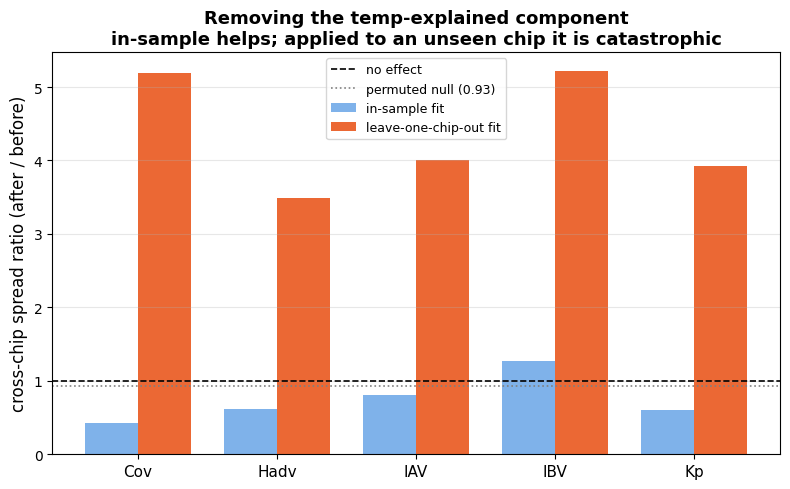

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(TARGETS)); w = 0.38
ax.bar(x - w/2, tab["in_sample"], w, label="in-sample fit", color="#7fb2ea")
ax.bar(x + w/2, tab["lofo_honest"], w, label="leave-one-chip-out fit", color="#eb6834")
ax.axhline(1.0, color="black", lw=1.2, ls="--", label="no effect")
ax.axhline(null.mean(), color="grey", lw=1.2, ls=":", label=f"permuted null ({null.mean():.2f})")
ax.set_xticks(x); ax.set_xticklabels(TARGETS, fontsize=11)
ax.set_ylabel("cross-chip spread ratio (after / before)", fontsize=12)
ax.set_title("Removing the temp-explained component\n"
             "in-sample helps; applied to an unseen chip it is catastrophic",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()